Using file: /content/Final_MasterDataset_upt.csv
Dataset loaded: (155, 25)
  Country  Year  D_Expenditure_GDP  Conflict_Intensity  \
0     CHN  1994           1.693480                 NaN   
1     CHN  1995           1.686234                 NaN   
2     CHN  1996           1.652727                 NaN   
3     CHN  1997           1.632651                 NaN   
4     CHN  1998           1.655081                 NaN   

   Health_Expenditure_GDP  Education_Expenditure_GDP  \
0                     NaN                    1.98571   
1                     NaN                    1.84192   
2                     NaN                    1.85339   
3                     NaN                        NaN   
4                     NaN                    1.84433   

   HealthExp_PerCapita_PPP_$  GovHealthExp_Pct_of_CHE  \
0                        NaN                      NaN   
1                        NaN                      NaN   
2                        NaN                      NaN   
3          

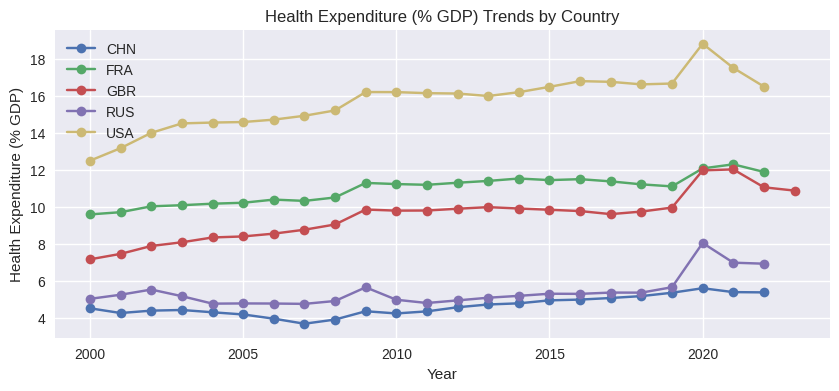

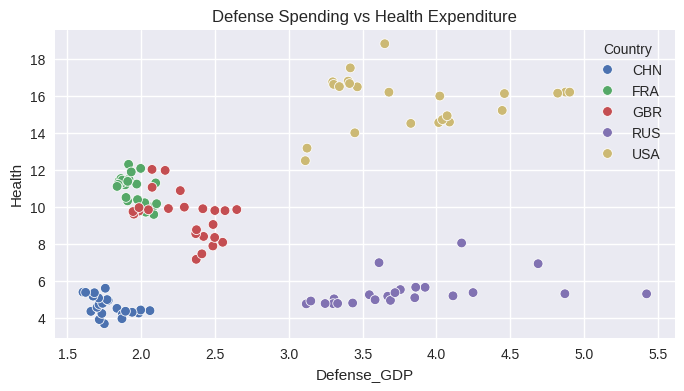

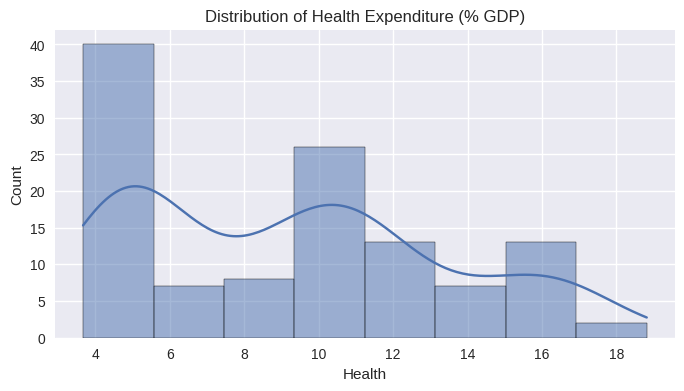

Remaining missing in features: 0
Remaining missing in target  : 39
Country one-hot columns: ['Country_CHN', 'Country_FRA', 'Country_GBR', 'Country_RUS', 'Country_USA']
Total step features: 24
Train raw rows: 115
Test/history rows: 145

Raw sequence shapes:
X_train_raw: (50, 5, 24) y_train_raw: (50,)
X_test_raw : (30, 5, 24) y_test_raw : (30,)

Scaled sequence shapes:
X_train: (50, 5, 24) y_train: (50,)
X_test : (30, 5, 24) y_test : (30,)

Train split:
X_tr : (35, 5, 24) y_tr : (35,)
X_val: (15, 5, 24) y_val: (15,)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 5, 64)          │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,289 (141.75 KB)

 Trainable params: 36,289 (141.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 261ms/step - loss: 0.3087 - val_loss: 0.2369 - learning_rate: 0.0010
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2125 - val_loss: 0.1585 - learning_rate: 0.0010
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1540 - val_loss: 0.0941 - learning_rate: 0.0010
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0959 - val_loss: 0.0478 - learning_rate: 0.0010
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0435 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0366 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0292 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0229 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0109 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 10/300
3/3 ━━━━━━━━━━

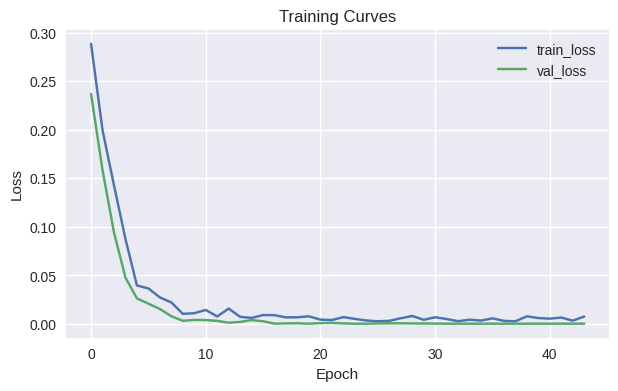


=== ONE-STEP TEST EVALUATION ===
Dropped rows due to NaNs: 0
Used rows for metrics: 30
Test MAE:  0.6837
Test RMSE: 0.9511
Test R2:   0.9508


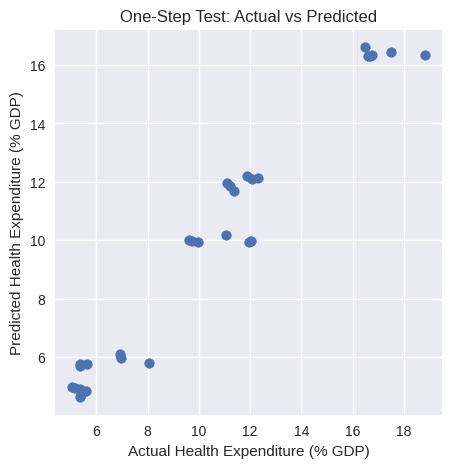


=== RECURSIVE BACKTEST (FEATURE FORECAST STYLE) ===
Rows used: 30
MAE:  0.6799
RMSE: 0.9581
R2:   0.9500


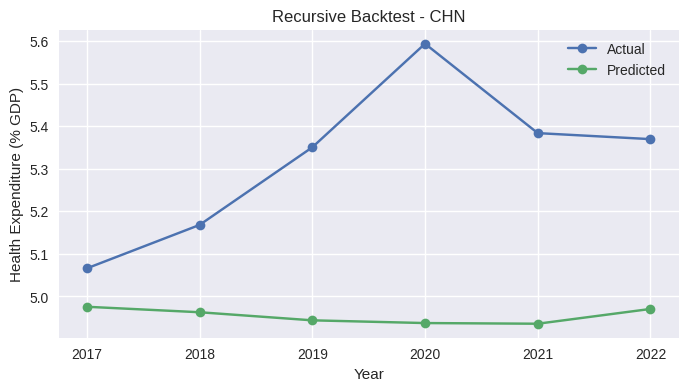

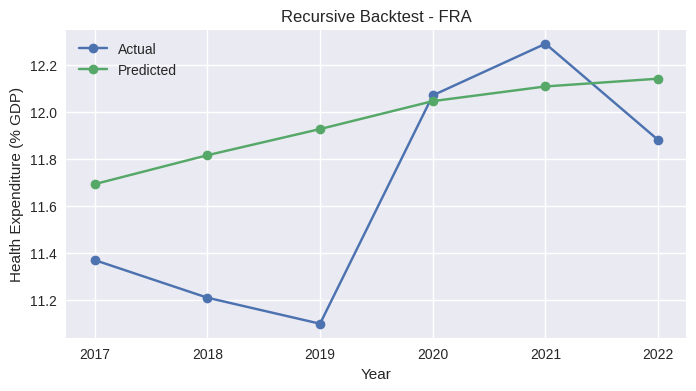

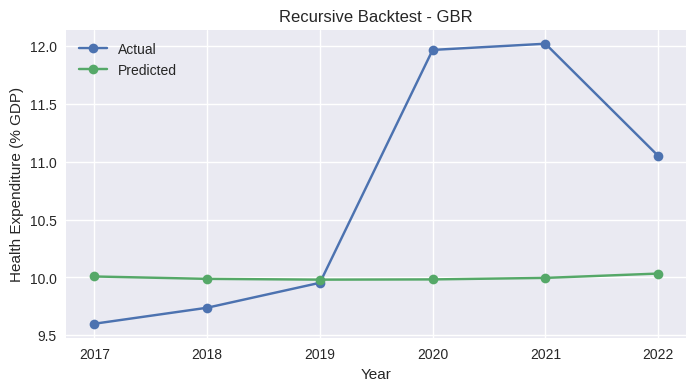

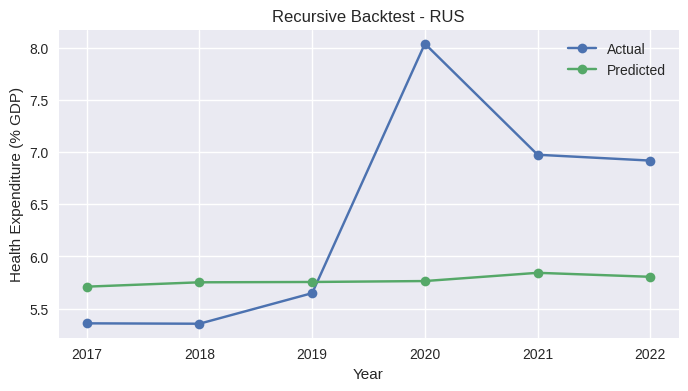

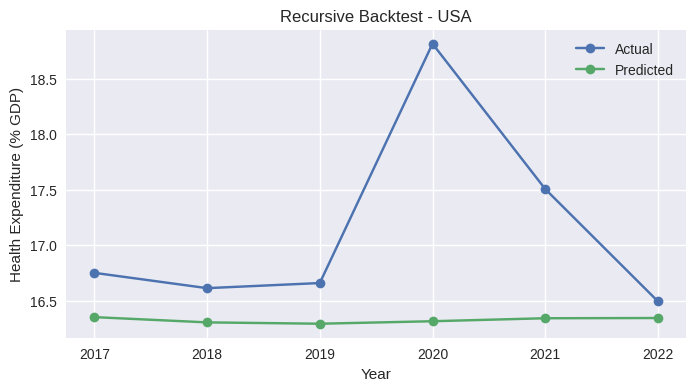


Saved files:
- health_feature_forecast_lstm.h5


In [5]:
import os
import random
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings("ignore")


# Reproducibility

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Config

TRAIN_END = 2016
TEST_START = 2017
TEST_END = 2022
VAL_START = 2014
LOOKBACK = 5

TARGET = "Health_Expenditure_GDP"


# Load Dataset

def resolve_data_path():
    candidate_paths = [
        "/content/Final_MasterDataset_upt.csv",
        "/content/Final_Master_Dataset.csv",
        "/mnt/data/Final_MasterDataset_upt.csv",
        "Final_MasterDataset_upt.csv",
        "Final_Master_Dataset.csv",
    ]
    for p in candidate_paths:
        if Path(p).exists():
            return p
    raise FileNotFoundError(
        "CSV file not found. Upload the file first or update the path."
    )

DATA_PATH = resolve_data_path()
print("Using file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

# Clean column names
df.columns = df.columns.str.strip()

# Ensure Year is numeric int
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

# Sort
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

print("Dataset loaded:", df.shape)
print(df.head())

# Drop fully empty columns
empty_cols = [c for c in df.columns if df[c].isna().all()]
if empty_cols:
    print("Dropping fully empty columns:", empty_cols)
    df = df.drop(columns=empty_cols)


# Feature Selection

core_features = [
    "Year",
    "D_Expenditure_GDP",
    "GDP_Growth_Annual",
    "Inflation_Annual",
    "Unemployment_Total_of_TLF",
    "Population",
    "GDP_Current_USDollars",
    "GDP_PerCapita_Growth_Annual"
]

health_features = [
    "HealthExp_PerCapita_PPP_$",
    "GovHealthExp_Pct_of_CHE",
    "GovHealthExp_PerCapita_PPP_$",
    "OutOfPocket_Pct_of_CHE",
    "Environmental_impact(CO2e/capita)",
    "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",
    "Refugees",
    "Asylum Seekers",
    "Total number of deaths"
]

base_features = core_features + health_features

required_cols = ["Country"] + base_features + [TARGET]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

health_df = df[required_cols].copy()

# Keep a safe helper label that does NOT conflict with one-hot dummy names
health_df["CountryLabel"] = health_df["Country"]

# Replace common placeholders
health_df = health_df.replace(["--", "-", "—", "N/A", "na", "NaN", ""], np.nan)

# Force numeric conversion
for c in base_features + [TARGET]:
    health_df[c] = pd.to_numeric(health_df[c], errors="coerce")

# Sort
health_df = health_df.sort_values(["CountryLabel", "Year"]).reset_index(drop=True)

print("\nSelected base features:", len(base_features))
print("Target:", TARGET)



# Quick EDA Graphs

eda_df = health_df[["Country", "Year", "D_Expenditure_GDP", TARGET]].copy()

# Health trend by country
plt.figure(figsize=(10, 4))
for c in eda_df["Country"].dropna().unique():
    cdf = eda_df[eda_df["Country"] == c].sort_values("Year")
    plt.plot(cdf["Year"], cdf[TARGET], marker="o", label=c)

plt.title("Health Expenditure (% GDP) Trends by Country")
plt.xlabel("Year")
plt.ylabel("Health Expenditure (% GDP)")
plt.legend()
plt.show()

# Defense vs Health scatter
plt.figure(figsize=(8, 4))
scatter_df = eda_df.dropna(subset=["D_Expenditure_GDP", TARGET, "Country"]).copy()
sns.scatterplot(
    data=scatter_df,
    x="D_Expenditure_GDP",
    y=TARGET,
    hue="Country"
)
plt.title("Defense Spending vs Health Expenditure")
plt.xlabel("Defense_GDP")
plt.ylabel("Health")
plt.show()

# Health distribution
plt.figure(figsize=(8, 4))
sns.histplot(eda_df[TARGET].dropna(), kde=True)
plt.title("Distribution of Health Expenditure (% GDP)")
plt.xlabel("Health")
plt.show()


# Impute FEATURES only (Do NOT impute target)

def fill_features(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("Year").copy()
    group[base_features] = group[base_features].interpolate(
        method="linear", limit_direction="both"
    )
    group[base_features] = group[base_features].ffill().bfill()
    return group

health_df = health_df.groupby("CountryLabel", group_keys=False).apply(fill_features)

print("Remaining missing in features:", int(health_df[base_features].isna().sum().sum()))
print("Remaining missing in target  :", int(health_df[TARGET].isna().sum()))


# Add Target Lags (Helps anchor health level)

health_df["Health_lag1"] = health_df.groupby("CountryLabel")[TARGET].shift(1)
health_df["Health_lag2"] = health_df.groupby("CountryLabel")[TARGET].shift(2)

lag_features = ["Health_lag1", "Health_lag2"]
X_COLS = base_features + lag_features


# One-Hot Encode Country

enc_df = pd.get_dummies(health_df, columns=["Country"], drop_first=False)

# ONLY real one hot dummy columns
country_cols = [c for c in enc_df.columns if c.startswith("Country_")]
enc_df[country_cols] = enc_df[country_cols].astype("int8")

# Preserve raw year
enc_df["Year_raw"] = enc_df["Year"]

# Final per step sequence features
STEP_FEATURE_COLS = X_COLS + country_cols

print("Country one-hot columns:", country_cols)
print("Total step features:", len(STEP_FEATURE_COLS))


# Split Raw Frames

train_enc = enc_df[enc_df["Year_raw"] <= TRAIN_END].copy()
test_enc = enc_df[enc_df["Year_raw"] <= TEST_END].copy()

print("Train raw rows:", train_enc.shape[0])
print("Test/history rows:", test_enc.shape[0])


# Build Raw Sequences

def build_sequences_raw(df_frame, lookback, feature_cols, target_col, target_year_min, target_year_max):
    X_list, y_list = [], []
    meta_country, meta_year = [], []

    for country_name, g in df_frame.groupby("CountryLabel", sort=False):
        g = g.sort_values("Year_raw").reset_index(drop=True)

        years_raw = g["Year_raw"].values
        X_vals = g[feature_cols].values.astype(float)
        y_vals = g[target_col].values.astype(float)

        for i in range(lookback, len(g)):
            y_year = years_raw[i]

            if not (target_year_min <= y_year <= target_year_max):
                continue


            window_years = years_raw[i - lookback : i + 1]
            if np.any(np.diff(window_years) != 1):
                continue

            X_seq = X_vals[i - lookback : i]

            # Skip if any NaN in input sequence
            if np.isnan(X_seq).any():
                continue

            # Skip if target missing
            if np.isnan(y_vals[i]):
                continue

            X_list.append(X_seq)
            y_list.append(y_vals[i])
            meta_country.append(country_name)
            meta_year.append(int(y_year))

    if len(X_list) == 0:
        return (
            np.empty((0, lookback, len(feature_cols)), dtype=float),
            np.empty((0,), dtype=float),
            np.empty((0,), dtype=object),
            np.empty((0,), dtype=int),
        )

    return (
        np.array(X_list, dtype=float),
        np.array(y_list, dtype=float),
        np.array(meta_country),
        np.array(meta_year, dtype=int),
    )

X_train_raw, y_train_raw, train_country_meta, y_train_years = build_sequences_raw(
    df_frame=train_enc,
    lookback=LOOKBACK,
    feature_cols=STEP_FEATURE_COLS,
    target_col=TARGET,
    target_year_min=int(train_enc["Year_raw"].min()) + LOOKBACK,
    target_year_max=TRAIN_END
)

X_test_raw, y_test_raw, test_country_meta, y_test_years = build_sequences_raw(
    df_frame=test_enc,
    lookback=LOOKBACK,
    feature_cols=STEP_FEATURE_COLS,
    target_col=TARGET,
    target_year_min=TEST_START,
    target_year_max=TEST_END
)

print("\nRaw sequence shapes:")
print("X_train_raw:", X_train_raw.shape, "y_train_raw:", y_train_raw.shape)
print("X_test_raw :", X_test_raw.shape,  "y_test_raw :", y_test_raw.shape)

if X_train_raw.shape[0] == 0:
    raise ValueError("No training sequences generated. Check lookback or missing-data pattern.")


# Scale Sequences
#     scale only numeric feature columns
#     keep one-hot columns unchanged

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

n_num_features = len(X_COLS)
n_total_features = len(STEP_FEATURE_COLS)

# Fit numeric feature scaler on all training timesteps
x_scaler.fit(X_train_raw[:, :, :n_num_features].reshape(-1, n_num_features))

# Fit target scaler on training targets
y_scaler.fit(y_train_raw.reshape(-1, 1))

def scale_sequence_array(X_seq_raw):
    if X_seq_raw.shape[0] == 0:
        return np.empty((0, LOOKBACK, n_total_features), dtype=float)

    X_scaled = X_seq_raw.copy().astype(float)

    num_part = X_scaled[:, :, :n_num_features].reshape(-1, n_num_features)
    num_scaled = x_scaler.transform(num_part).reshape(
        X_scaled.shape[0], X_scaled.shape[1], n_num_features
    )

    X_scaled[:, :, :n_num_features] = num_scaled
    return X_scaled

X_train = scale_sequence_array(X_train_raw)
X_test = scale_sequence_array(X_test_raw)

y_train = y_scaler.transform(y_train_raw.reshape(-1, 1)).flatten()
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1)).flatten() if len(y_test_raw) > 0 else np.array([])

print("\nScaled sequence shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


# Time-Based Validation


val_mask = (y_train_years >= VAL_START)

X_tr, y_tr = X_train[~val_mask], y_train[~val_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]

print("\nTrain split:")
print("X_tr :", X_tr.shape,  "y_tr :", y_tr.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)

if X_tr.shape[0] == 0 or X_val.shape[0] == 0:
    raise ValueError("Train/validation split failed. Adjust VAL_START or inspect sequence generation.")


# Build LSTM Model

n_features = X_train.shape[-1]

model = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear")
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

cb_early = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

cb_reduce = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[cb_early, cb_reduce],
    verbose=1
)


# Training Curves

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curves")
plt.legend()
plt.show()


# One Step Test Evaluation

if X_test.shape[0] == 0:
    print("\nNo test sequences generated.")
    one_step_results = pd.DataFrame()
else:
    y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)

    y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    print("\n=== ONE-STEP TEST EVALUATION ===")
    print("Dropped rows due to NaNs:", int((~mask).sum()))
    print("Used rows for metrics:", int(mask.sum()))

    if mask.sum() == 0:
        one_step_results = pd.DataFrame()
    else:
        mae = mean_absolute_error(y_true_clean, y_pred_clean)
        rmse_val = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
        r2 = r2_score(y_true_clean, y_pred_clean)

        print(f"Test MAE:  {mae:.4f}")
        print(f"Test RMSE: {rmse_val:.4f}")
        print(f"Test R2:   {r2:.4f}")

        one_step_results = pd.DataFrame({
            "Country": test_country_meta[mask],
            "Year": y_test_years[mask],
            "Actual_Health": y_true_clean,
            "Predicted_Health": y_pred_clean
        })

        plt.figure(figsize=(5, 5))
        plt.scatter(y_true_clean, y_pred_clean)
        plt.xlabel("Actual Health Expenditure (% GDP)")
        plt.ylabel("Predicted Health Expenditure (% GDP)")
        plt.title("One-Step Test: Actual vs Predicted")
        plt.show()


# Scale a single step frame

def scale_step_frame(step_df):
    step_df = step_df.copy()
    step_df[X_COLS] = x_scaler.transform(step_df[X_COLS])
    return step_df


# Recursive Backtest

def recursive_backtest_feature_forecast():
    results = []

    countries = sorted(health_df["CountryLabel"].unique())

    for country_name in countries:
        country_col = f"Country_{country_name}"

        c_full = enc_df[enc_df[country_col] == 1].sort_values("Year_raw").reset_index(drop=True)
        c_train = c_full[c_full["Year_raw"] <= TRAIN_END].copy()
        c_test = c_full[(c_full["Year_raw"] >= TEST_START) & (c_full["Year_raw"] <= TEST_END)].copy()

        if len(c_train) < LOOKBACK or len(c_test) == 0:
            continue

        seed_rows = c_train.tail(LOOKBACK).copy()

        if seed_rows[STEP_FEATURE_COLS].isna().any().any():
            print(f"Skipping {country_name}: seed contains NaNs")
            continue

        if pd.isna(c_train.iloc[-1][TARGET]) or pd.isna(c_train.iloc[-2][TARGET]):
            print(f"Skipping {country_name}: last train target values are missing")
            continue

        seed_scaled = scale_step_frame(seed_rows[STEP_FEATURE_COLS].copy())
        seq = seed_scaled[STEP_FEATURE_COLS].values.astype(float)

        last_known = c_train.iloc[-1].copy()
        prev_row = c_train.iloc[-2].copy()

        # These represent the last two known health levels BEFORE the next prediction
        curr_lag1 = float(last_known[TARGET])   # latest known health
        curr_lag2 = float(prev_row[TARGET])     # second-latest known health

        frozen_feature_state = last_known.copy()

        for _, actual_row in c_test.iterrows():
            # Predict next health directly
            pred_scaled = model.predict(seq[np.newaxis, :, :], verbose=0)
            pred_health = float(y_scaler.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0])

            actual_health = actual_row[TARGET]

            if pd.notna(actual_health):
                results.append({
                    "Country": country_name,
                    "Year": int(actual_row["Year_raw"]),
                    "Actual_Health": float(actual_health),
                    "Predicted_Health": pred_health
                })

            # Build synthetic row for THIS forecasted year
            # Its lags should be the last two known values before this year's target
            next_row = frozen_feature_state.copy()
            next_row["Year"] = int(actual_row["Year_raw"])
            next_row["Year_raw"] = int(actual_row["Year_raw"])
            next_row["D_Expenditure_GDP"] = float(actual_row["D_Expenditure_GDP"])
            next_row["Health_lag1"] = curr_lag1
            next_row["Health_lag2"] = curr_lag2

            next_row_df = pd.DataFrame([next_row])[STEP_FEATURE_COLS].copy()
            next_row_scaled = scale_step_frame(next_row_df)

            seq = np.vstack([seq[1:], next_row_scaled[STEP_FEATURE_COLS].values.astype(float)])

            # After the year's prediction, move lag state forward
            curr_lag2 = curr_lag1
            curr_lag1 = pred_health

            frozen_feature_state["Year"] = int(actual_row["Year_raw"])
            frozen_feature_state["Year_raw"] = int(actual_row["Year_raw"])
            frozen_feature_state["D_Expenditure_GDP"] = float(actual_row["D_Expenditure_GDP"])

    return pd.DataFrame(results)

recursive_results = recursive_backtest_feature_forecast()

if recursive_results.empty:
    print("\nNo recursive backtest rows produced.")
else:
    mae_rec = mean_absolute_error(recursive_results["Actual_Health"], recursive_results["Predicted_Health"])
    rmse_rec = np.sqrt(mean_squared_error(recursive_results["Actual_Health"], recursive_results["Predicted_Health"]))
    r2_rec = r2_score(recursive_results["Actual_Health"], recursive_results["Predicted_Health"])

    print("\n=== RECURSIVE BACKTEST (FEATURE FORECAST STYLE) ===")
    print(f"Rows used: {len(recursive_results)}")
    print(f"MAE:  {mae_rec:.4f}")
    print(f"RMSE: {rmse_rec:.4f}")
    print(f"R2:   {r2_rec:.4f}")


# Plot Recursive Backtest by Country

if not recursive_results.empty:
    for c in sorted(recursive_results["Country"].unique()):
        cdf = recursive_results[recursive_results["Country"] == c].sort_values("Year")

        plt.figure(figsize=(8, 4))
        plt.plot(cdf["Year"], cdf["Actual_Health"], marker="o", label="Actual")
        plt.plot(cdf["Year"], cdf["Predicted_Health"], marker="o", label="Predicted")
        plt.title(f"Recursive Backtest - {c}")
        plt.xlabel("Year")
        plt.ylabel("Health Expenditure (% GDP)")
        plt.legend()
        plt.show()


# Future Scenario Forecast

def forecast_future_health(country_name, target_year, defense_gdp_value):
    country_col = f"Country_{country_name}"

    if country_col not in enc_df.columns:
        raise ValueError(f"Unknown country: {country_name}")

    c = enc_df[enc_df[country_col] == 1].sort_values("Year_raw").reset_index(drop=True)

    if len(c) < LOOKBACK:
        raise ValueError(f"Not enough history for {country_name}")

    if pd.isna(c.iloc[-1][TARGET]) or pd.isna(c.iloc[-2][TARGET]):
        raise ValueError(f"Last known target values for {country_name} are missing")

    last_available_year = int(c.iloc[-1]["Year_raw"])
    if target_year <= last_available_year:
        raise ValueError(f"target_year must be greater than {last_available_year}")

    seed_rows = c.tail(LOOKBACK).copy()

    if seed_rows[STEP_FEATURE_COLS].isna().any().any():
        raise ValueError(f"Seed rows for {country_name} contain NaNs")

    seed_scaled = scale_step_frame(seed_rows[STEP_FEATURE_COLS].copy())
    seq = seed_scaled[STEP_FEATURE_COLS].values.astype(float)

    last_known = c.iloc[-1].copy()
    prev_row = c.iloc[-2].copy()

    # Last two known health levels BEFORE the next forecast year
    curr_lag1 = float(last_known[TARGET])
    curr_lag2 = float(prev_row[TARGET])

    frozen_feature_state = last_known.copy()

    future_rows = []

    for yr in range(last_available_year + 1, target_year + 1):
        pred_scaled = model.predict(seq[np.newaxis, :, :], verbose=0)
        pred_health = float(y_scaler.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0])

        future_rows.append({
            "Country": country_name,
            "Year": yr,
            "Input_Defense_GDP": float(defense_gdp_value),
            "Predicted_Health_Expenditure_GDP": pred_health
        })

        # Build synthetic row for THIS forecasted year
        next_row = frozen_feature_state.copy()
        next_row["Year"] = yr
        next_row["Year_raw"] = yr
        next_row["D_Expenditure_GDP"] = float(defense_gdp_value)

        # lag logic: row for year t uses values from t-1 and t-2
        next_row["Health_lag1"] = curr_lag1
        next_row["Health_lag2"] = curr_lag2

        next_row_df = pd.DataFrame([next_row])[STEP_FEATURE_COLS].copy()
        next_row_scaled = scale_step_frame(next_row_df)

        seq = np.vstack([seq[1:], next_row_scaled[STEP_FEATURE_COLS].values.astype(float)])

        # Move lag state forward after prediction
        curr_lag2 = curr_lag1
        curr_lag1 = pred_health

        frozen_feature_state["Year"] = yr
        frozen_feature_state["Year_raw"] = yr
        frozen_feature_state["D_Expenditure_GDP"] = float(defense_gdp_value)

    return pd.DataFrame(future_rows)


# Multi Country Forecast Helper

def forecast_multiple_countries(country_list, target_year, defense_gdp_value):
    outputs = []
    for country_name in country_list:
        out = forecast_future_health(
            country_name=country_name,
            target_year=target_year,
            defense_gdp_value=defense_gdp_value
        )
        outputs.append(out)

    if not outputs:
        return pd.DataFrame()

    return pd.concat(outputs, ignore_index=True)



# Save Model

model.save("health_feature_forecast_lstm.h5", save_format="h5")
# joblib.dump(x_scaler, "health_x_scaler.pkl")
# joblib.dump(y_scaler, "health_y_scaler.pkl")

# metadata = {
#     "target": TARGET,
#     "base_features": base_features,
#     "lag_features": lag_features,
#     "x_cols": X_COLS,
#     "country_cols": country_cols,
#     "step_feature_cols": STEP_FEATURE_COLS,
#     "lookback": LOOKBACK,
#     "train_years": (int(train_enc["Year_raw"].min()), TRAIN_END),
#     "val_years": (VAL_START, TRAIN_END),
#     "test_years": (TEST_START, TEST_END),
#     "countries": sorted(health_df["CountryLabel"].unique().tolist())
# }
# joblib.dump(metadata, "health_feature_forecast_metadata.pkl")

# enc_df.to_csv("health_feature_forecast_processed.csv", index=False)

print("\nSaved files:")
print("- health_feature_forecast_lstm.h5")
# print("- health_x_scaler.pkl")
# print("- health_y_scaler.pkl")
# print("- health_feature_forecast_metadata.pkl")
# print("- health_feature_forecast_processed.csv")